# Task 5 — Convergence Rate: ReLU vs Sigmoid vs Tanh
Use the **same architecture** for all three activations and compare:
- How fast each activation reaches a target validation accuracy
- Smoothness of the loss curve
- Final performance after 100 epochs

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.21.0


## 1. Load & Prepare Data

In [4]:
df = pd.read_csv('datasets/house_prices.csv')

median_price = df['price'].median()

df['price_category'] = (df['price'] >= median_price).astype(int)

X = df[['sqft_living', 'bedrooms']].values

y = df['price_category'].values

scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {len(X_train)} | Test: {len(X_test)}')

Train: 17290 | Test: 4323


## 2. Train All Three — 100 Epochs (more epochs = clearer convergence difference)

In [5]:
ACTIVATIONS = ['relu', 'sigmoid', 'tanh']
EPOCHS      = 100
results     = {}

for act in ACTIVATIONS:
    tf.random.set_seed(42)   # same init for fair comparison
    model = keras.Sequential([
        layers.Input(shape=(2,)),
        layers.Dense(16, activation=act),
        layers.Dense(16, activation=act),
        layers.Dense(1,  activation='sigmoid'),
    ], name=f'model_{act}')
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    print(f'Training {act.upper()} ...')
    history = model.fit(
        X_train, y_train,
        epochs=EPOCHS,
        batch_size=32,
        validation_split=0.1,
        verbose=0
    )
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    results[act] = {'history': history, 'test_acc': acc, 'test_loss': loss}
    print(f'  Done → Test Acc: {acc*100:.2f}%  Loss: {loss:.4f}')

Training RELU ...
  Done → Test Acc: 72.43%  Loss: 0.5290
Training SIGMOID ...
  Done → Test Acc: 72.38%  Loss: 0.5311
Training TANH ...
  Done → Test Acc: 72.20%  Loss: 0.5299


## 3. Convergence Analysis — Epochs to Reach Thresholds

In [6]:
thresholds = [0.70, 0.75, 0.80, 0.85]

rows = []
for act in ACTIVATIONS:
    val_acc = results[act]['history'].history['val_accuracy']
    row = {'Activation': act.upper()}
    for t in thresholds:
        ep = next((i+1 for i, a in enumerate(val_acc) if a >= t), None)
        row[f'>={int(t*100)}% val_acc'] = ep if ep else 'not reached'
    row['Final Val Acc']  = f"{val_acc[-1]*100:.2f}%"
    row['Final Test Acc'] = f"{results[act]['test_acc']*100:.2f}%"
    rows.append(row)

conv_df = pd.DataFrame(rows).set_index('Activation')
conv_df

,>=70% val_acc,>=75% val_acc,>=80% val_acc,>=85% val_acc,Final Val Acc,Final Test Acc
Activation,,,,,,
RELU,1,not reached,not reached,not reached,70.85%,72.43%
SIGMOID,5,not reached,not reached,not reached,71.31%,72.38%
TANH,1,not reached,not reached,not reached,71.26%,72.20%


## 4. Plot — Convergence Curves (Val Accuracy)

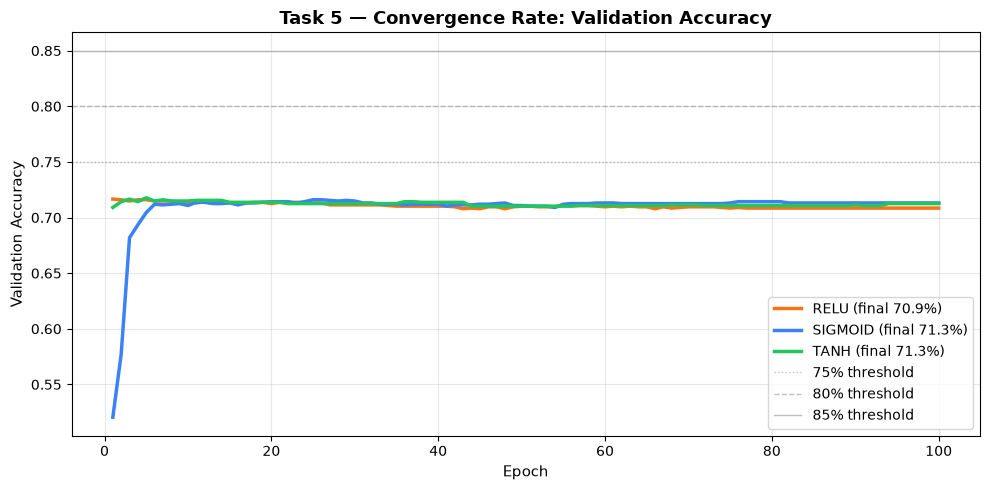

In [7]:
COLORS   = {'relu': '#f97316', 'sigmoid': '#3b82f6', 'tanh': '#22c55e'}
epochs_x = range(1, EPOCHS + 1)

fig, ax = plt.subplots(figsize=(10, 5))

for act in ACTIVATIONS:
    val_acc = results[act]['history'].history['val_accuracy']
    ax.plot(epochs_x, val_acc, color=COLORS[act], lw=2.5, label=f'{act.upper()} (final {val_acc[-1]*100:.1f}%)')

# Threshold lines
for t, ls in zip([0.75, 0.80, 0.85], [':', '--', '-']):
    ax.axhline(t, color='gray', lw=1, ls=ls, alpha=0.5, label=f'{int(t*100)}% threshold')

ax.set_title('Task 5 — Convergence Rate: Validation Accuracy', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Validation Accuracy', fontsize=11)
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Plot — Convergence Curves (Val Loss)

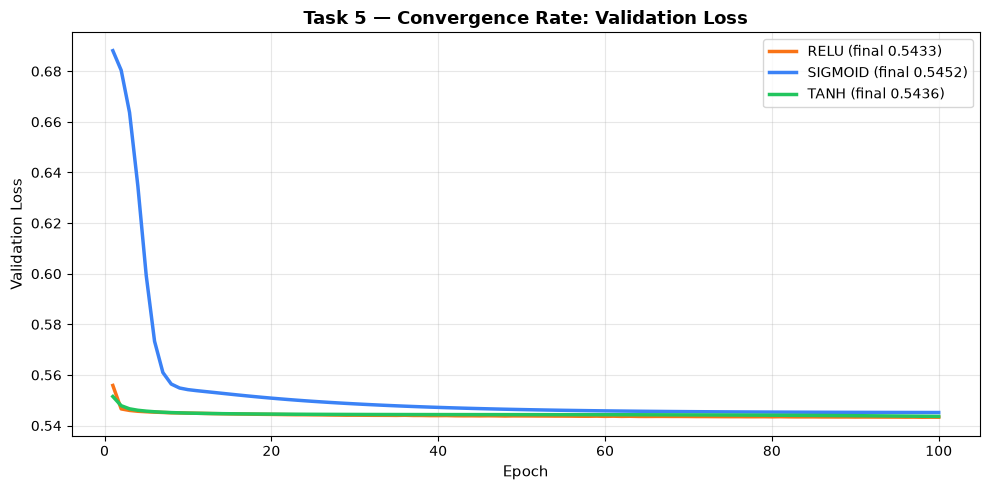

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))

for act in ACTIVATIONS:
    val_loss = results[act]['history'].history['val_loss']
    ax.plot(epochs_x, val_loss, color=COLORS[act], lw=2.5,
            label=f'{act.upper()} (final {val_loss[-1]:.4f})')

ax.set_title('Task 5 — Convergence Rate: Validation Loss', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Validation Loss', fontsize=11)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Plot — Full 4-Panel Comparison

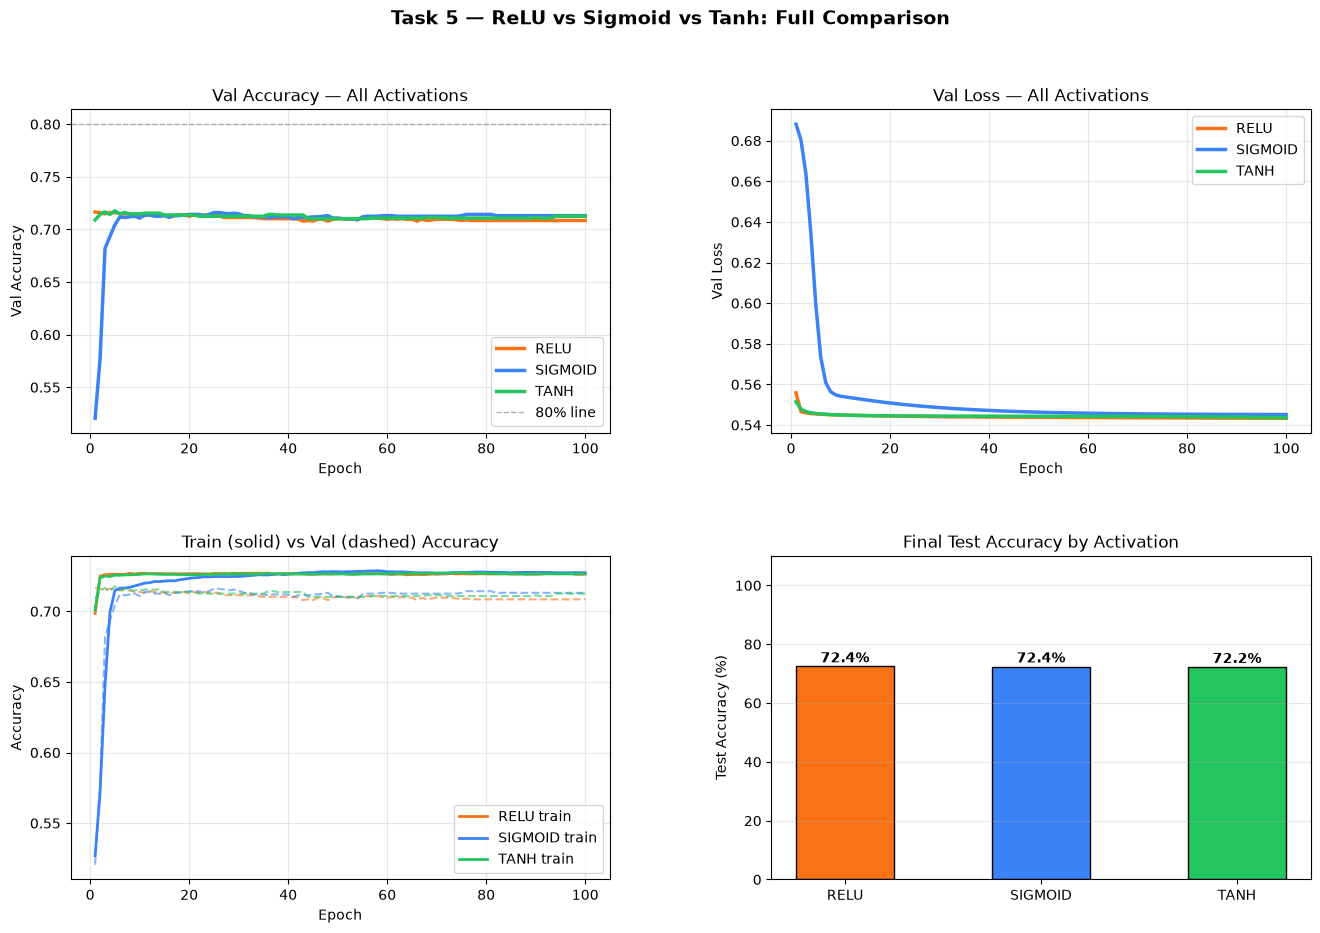

Plot saved to task5_convergence.png


In [9]:
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.3)

# Panel 1 — Val accuracy overlay
ax1 = fig.add_subplot(gs[0, 0])
for act in ACTIVATIONS:
    ax1.plot(epochs_x, results[act]['history'].history['val_accuracy'],
             color=COLORS[act], lw=2.5, label=act.upper())
ax1.axhline(0.80, color='gray', lw=1, ls='--', alpha=0.6, label='80% line')
ax1.set_title('Val Accuracy — All Activations'); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Val Accuracy')
ax1.legend(); ax1.grid(alpha=0.3)

# Panel 2 — Val loss overlay
ax2 = fig.add_subplot(gs[0, 1])
for act in ACTIVATIONS:
    ax2.plot(epochs_x, results[act]['history'].history['val_loss'],
             color=COLORS[act], lw=2.5, label=act.upper())
ax2.set_title('Val Loss — All Activations'); ax2.set_xlabel('Epoch'); ax2.set_ylabel('Val Loss')
ax2.legend(); ax2.grid(alpha=0.3)

# Panel 3 — Train accuracy per activation (individual sublines)
ax3 = fig.add_subplot(gs[1, 0])
for act in ACTIVATIONS:
    h = results[act]['history'].history
    ax3.plot(epochs_x, h['accuracy'],     color=COLORS[act], lw=2,   label=f'{act.upper()} train')
    ax3.plot(epochs_x, h['val_accuracy'], color=COLORS[act], lw=1.5, ls='--', alpha=0.6)
ax3.set_title('Train (solid) vs Val (dashed) Accuracy')
ax3.set_xlabel('Epoch'); ax3.set_ylabel('Accuracy')
ax3.legend(); ax3.grid(alpha=0.3)

# Panel 4 — Bar: test accuracy + test loss
ax4 = fig.add_subplot(gs[1, 1])
x    = np.arange(len(ACTIVATIONS))
acts = [a.upper() for a in ACTIVATIONS]
accs = [results[a]['test_acc'] * 100 for a in ACTIVATIONS]
bars = ax4.bar(x, accs, color=[COLORS[a] for a in ACTIVATIONS],
               edgecolor='black', width=0.5)
for bar, acc in zip(bars, accs):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{acc:.1f}%', ha='center', va='bottom', fontweight='bold')
ax4.set_xticks(x); ax4.set_xticklabels(acts)
ax4.set_ylim(0, 110); ax4.set_ylabel('Test Accuracy (%)')
ax4.set_title('Final Test Accuracy by Activation')
ax4.grid(axis='y', alpha=0.3)

fig.suptitle('Task 5 — ReLU vs Sigmoid vs Tanh: Full Comparison', fontsize=14, fontweight='bold')
plt.savefig('task5_convergence.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved to task5_convergence.png')

## 7. Key Takeaways

In [10]:
print('== Convergence Summary ==')
for act in ACTIVATIONS:
    val_acc = results[act]['history'].history['val_accuracy']
    val_loss = results[act]['history'].history['val_loss']
    ep_80 = next((i+1 for i, a in enumerate(val_acc) if a >= 0.80), None)
    print(f'{act.upper():>8} | Final val_acc: {val_acc[-1]*100:.2f}% | '
          f'Final val_loss: {val_loss[-1]:.4f} | '
          f'Epochs to >80% val_acc: {ep_80 if ep_80 else "not reached"}')

print()
print('Notes:')
print('  ReLU    — fastest convergence, avoids vanishing gradient, best for deep nets')
print('  Tanh    — smoother than sigmoid, zero-centered, good for shallow nets')
print('  Sigmoid — slowest due to vanishing gradient; saturates at extremes')

== Convergence Summary ==
    RELU | Final val_acc: 70.85% | Final val_loss: 0.5433 | Epochs to >80% val_acc: not reached
 SIGMOID | Final val_acc: 71.31% | Final val_loss: 0.5452 | Epochs to >80% val_acc: not reached
    TANH | Final val_acc: 71.26% | Final val_loss: 0.5436 | Epochs to >80% val_acc: not reached

Notes:
  ReLU    — fastest convergence, avoids vanishing gradient, best for deep nets
  Tanh    — smoother than sigmoid, zero-centered, good for shallow nets
  Sigmoid — slowest due to vanishing gradient; saturates at extremes
